In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
plt.rc('font',family='Arial')
plt.rcParams['axes.unicode_minus']=False
plt.rcParams['font.size'] = 9

import time
start_time = time.time()
print(time.ctime())

from dynamic_stock_model import DynamicStockModel

file_path = 'C:/Users/xmuxi/Desktop/2-UCAS/4-Co-Ni-Cu/Data/'

Sun Aug  2 15:47:42 2026


In [2]:
Regions = ['China','Japan','EU','USA','RoW']
Region_Colors = ['#D62728','#2CA02C','#FF7F0E','#1F77B4','#7F7F7F']

Lifetime_Scenarios = ['Constant','Longer']

Sectors = ['Building & Construction','Infrastructure','Transport','Industrial Equipment','Other Products']
New_Sectors = ['Building & Construction','Infrastructure','Transport (Exclude B-EVs)','Industrial Equipment','Other Products (Exclude B-ESS)', 'B-ESS', 'B-EVs']
Old_Sectors = ['Building & Construction','Infrastructure','Transport (Exclude B-EVs)','Industrial Equipment','Other Products (Exclude B-ESS)']
Agg_Sectors = ['Building & Infrastructure','Transportation','Industrial Equipment','B-CEs','B-EVs','B-ESS',]

## 蓝色系列
sector_color_dict = {'Building & Construction': '#C6DBEF', 
                     'Infrastructure': '#9ECAE1', 
                     'Building & Infrastructure': '#C6DBEF', 
                     
                     'Transport': '#6BAED6', 
                     'Transport (Exclude B-EVs)': '#6BAED6', 
                     'Transportation': '#6BAED6', 
                     
                     'Industrial Equipment': '#3182BD',
                     
                     'Other Products':'#08519C',  
                     'Other Products (Exclude B-ESS)':'#08519C',
                     
                     'B-CEs': '#FDAE6B',
                     'B-EVs': '#F16913',
                     'B-ESS': '#8C2D04'}

New_Sector_Colors = [sector_color_dict[s] for s in New_Sectors]
Old_Sector_Colors = [sector_color_dict[s] for s in Old_Sectors]
Agg_Sector_Colors = [sector_color_dict[s] for s in Agg_Sectors]

## Demand: Top-down (Traditional use)
- population (million persons)

In [3]:
df_pop = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Copper_compile_data_world.xlsx', sheet_name='Population', index_col=[0], header=2)
df_pop.tail(2)

,China,Japan,EU,USA,RoW,World
Region,,,,,,
2049,1280.759386,109.228545,540.774244,400.449494,6787.051188,9118.262858
2050,1272.404764,108.608700,541.109188,402.305227,6827.682758,9152.110636


- per capita traditional use (kg/person)

In [4]:
df_per_capita = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Copper_compile_data_world.xlsx', sheet_name='per capita traditional use', index_col=[0], header=[5])
df_per_capita.tail(2)

,Building & Construction,Infrastructure,Transport (Exclude B-EVs),Industrial Equipment,Other Products (Exclude B-ESS),Total
Sector,,,,,,
2099,59.997965,30.0,19.999995,14.999684,14.999997,139.997641
2100,59.998834,30.0,19.999998,14.999815,14.999999,139.998646


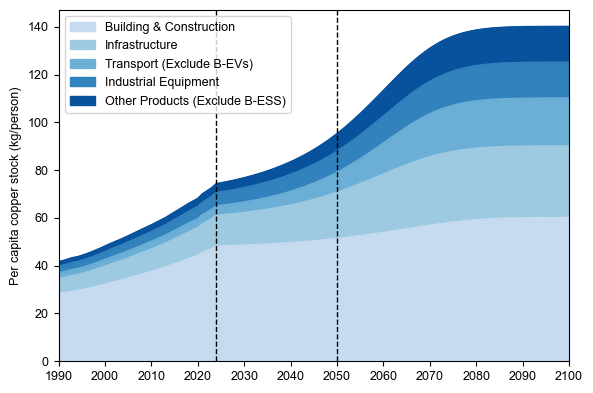

In [5]:
def plot_per_capita(df):
    year_min = 1990
    
    fig, ax = plt.subplots(1,1, figsize=(6, 4))
    df.plot.area(ax=ax, y=Old_Sectors, color=Old_Sector_Colors, legend=True)
            
    ax.set_xlim(year_min, 2100)
    ax.set_xticks(np.arange(year_min, 2101, 10))
    ax.set_ylabel('Per capita copper stock (kg/person)')
    ax.set_xlabel('')
    ax.axvline(x=2024, color="black", linestyle="--", lw=1)
    ax.axvline(x=2050, color="black", linestyle="--", lw=1)
    
    #plt.legend(frameon=False)
    plt.savefig(file_path + r'Sector_Cu_Ni_Co/Copper_per_capita_stock.png', bbox_inches='tight', pad_inches=.1, dpi=300)
    plt.tight_layout()
    plt.show()
    
    
plot_per_capita(df_per_capita)

- lifetime distribution

In [6]:
df_per_capita = df_per_capita.loc[:2050:]
df_per_capita.tail(2)

,Building & Construction,Infrastructure,Transport (Exclude B-EVs),Industrial Equipment,Other Products (Exclude B-ESS),Total
Sector,,,,,,
2049,51.025553,18.937606,7.981351,8.650224,7.054912,93.649647
2050,51.235015,19.378207,8.327024,8.856932,7.322852,95.120030


In [7]:
df_lifetime = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Copper_compile_data_world.xlsx', sheet_name='lifetime', index_col=[0,1], header=2)
df_lifetime = df_lifetime.T
df_lifetime.tail(2)

Lifetime Scenario                Constant                                 \
Sector            Building & Construction Infrastructure B-EVs Transport   
2049                                 40.0           34.0   NaN      17.0   
2050                                 40.0           34.0   NaN      17.0   

Lifetime Scenario                                                       \
Sector            Transport (Exclude B-EVs) Industrial Equipment B-ESS   
2049                                   17.0                 17.0   NaN   
2050                                   17.0                 17.0   NaN   

Lifetime Scenario                                                \
Sector            Other Products Other Products (Exclude B-ESS)   
2049                        13.0                           13.0   
2050                        13.0                           13.0   

Lifetime Scenario                  Longer                                  \
Sector            Building & Construction Infrastructure B-EVs  Transport   
2049                            51.810253      44.038715   NaN  22.019357   
2050                            52.328355      44.479102   NaN  22.239551   

Lifetime Scenario                                                       \
Sector            Transport (Exclude B-EVs) Industrial Equipment B-ESS   
2049                              22.019357            22.019357   NaN   
2050                              22.239551            22.239551   NaN   

Lifetime Scenario                                                
Sector            Other Products Other Products (Exclude B-ESS)  
2049                   16.838332                      16.838332  
2050                   17.006715                      17.006715

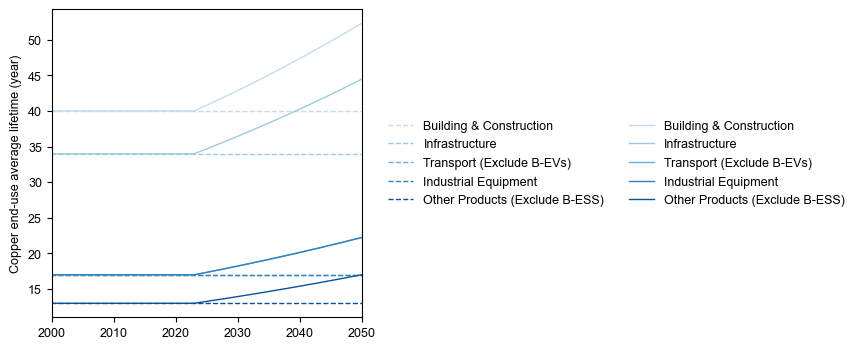

In [8]:
def plot_lifetime(df):
    year_min = 2000
    
    fig, ax = plt.subplots(1,1, figsize=(4,4))
    
    for sector in Old_Sectors:
        ax.plot(df.index, df['Constant',sector], label=sector, color=sector_color_dict[sector], lw=1, linestyle='--')
        
    for sector in Old_Sectors:
        ax.plot(df.index, df['Longer',sector], label=sector, color=sector_color_dict[sector], lw=1)
        
    ax.set_ylabel('Copper end-use average lifetime (year)')
    ax.set_xlim(year_min,2050)
    ax.set_xticks(np.arange(year_min,2051,10))
    ax.legend(frameon=False, ncol=2, loc='center left', bbox_to_anchor=(1.05,0.5))
    
    #plt.savefig(file_path + r'Sector_Cu_Ni_Co\Copper_Enduse_Lifetime.png', bbox_inches='tight', pad_inches=.1, dpi=300)
    plt.show()
    
    
plot_lifetime(df_lifetime)

- Traditional use
- stock, inflow, outflow
- million persons * kg/person = kt

In [9]:
def cal_traditional_stock_flow(df_pop, df_capita, df_lt):
    
    df_stock = pd.DataFrame(index=df_capita.index, 
                             columns=pd.MultiIndex.from_product([Lifetime_Scenarios,Old_Sectors],names=['Lifetime','Sector']))
    df_inflow = df_stock.copy()
    df_outflow = df_inflow.copy()
    
    for lt in Lifetime_Scenarios:
        for s in Old_Sectors:
            df_stock[(lt,s)] = df_pop['World'] * df_capita[s]
            ## stock-driven
            DSM = DynamicStockModel(t = list(df_stock.index), 
                                    s = list(df_stock[(lt,s)]), 
                                    lt = {'Type': 'Normal',
                                          'Mean': list(df_lt[(lt,s)]),    
                                          'StdDev': list(0.3 * df_lt[(lt,s)])})
            DSM.compute_stock_driven_model()
            DSM.compute_outflow_total()
            ## fill in
            df_inflow[(lt,s)] = DSM.i
            df_outflow[(lt,s)] = DSM.o
                
    ## 第二轮
    df_inflow_2 = df_inflow.mask(df_inflow<0, 0)
    df_stock_2 = pd.DataFrame(index=df_capita.index, 
                              columns=pd.MultiIndex.from_product([Lifetime_Scenarios,Old_Sectors],names=['Lifetime','Sector']))
    df_outflow_2 = df_stock_2.copy()
    
    for lt in Lifetime_Scenarios:
        for s in Old_Sectors:
            ## inflow-driven
            DSM = DynamicStockModel(t = list(df_inflow_2.index), 
                                    i = list(df_inflow_2[(lt,s)]), 
                                    lt = {'Type': 'Normal',
                                          'Mean': list(df_lt[(lt,s)]),    
                                          'StdDev': list(0.3 * df_lt[(lt,s)])})
            DSM.compute_s_c_inflow_driven()
            DSM.compute_stock_total()
            DSM.compute_o_c_from_s_c()
            DSM.compute_outflow_total()
            ## fill in 
            df_stock_2[(lt,s)] = DSM.s
            df_outflow_2[(lt,s)] = DSM.o
                
    return df_stock_2, df_inflow_2, df_outflow_2


df_traditional_stock, df_traditional_inflow, df_traditional_outflow = cal_traditional_stock_flow(df_pop, df_per_capita, df_lifetime)
df_traditional_inflow.tail(2)

Lifetime                Constant                                           \
Sector   Building & Construction Infrastructure Transport (Exclude B-EVs)   
Sector                                                                      
2049                13636.470453    8029.397447               6113.698414   
2050                13895.621879    8295.490841               6444.371010   

Lifetime                                                      \
Sector   Industrial Equipment Other Products (Exclude B-ESS)   
Sector                                                         
2049              5680.291415                    6208.680534   
2050              5856.586270                    6489.182234   

Lifetime                  Longer                                           \
Sector   Building & Construction Infrastructure Transport (Exclude B-EVs)   
Sector                                                                      
2049                13438.093899    7876.147681               5592.481572   
2050                13658.769525    8112.159752               5874.979021   

Lifetime                                                      
Sector   Industrial Equipment Other Products (Exclude B-ESS)  
Sector                                                        
2049              5067.735915                    5535.112548  
2050              5196.353324                    5754.869555

In [10]:
df_traditional_stock.tail(2)

Lifetime                Constant                                           \
Sector   Building & Construction Infrastructure Transport (Exclude B-EVs)   
Sector                                                                      
2049               465264.403750  172678.073321              72776.056515   
2050               468908.529479  177351.496259              76209.842823   

Lifetime                                                      \
Sector   Industrial Equipment Other Products (Exclude B-ESS)   
Sector                                                         
2049             78875.018272                   64328.544074   
2050             81059.618896                   67019.552822   

Lifetime                  Longer                                           \
Sector   Building & Construction Infrastructure Transport (Exclude B-EVs)   
Sector                                                                      
2049               465264.403750  172678.073321              72776.056515   
2050               468908.529479  177351.496259              76209.842823   

Lifetime                                                      
Sector   Industrial Equipment Other Products (Exclude B-ESS)  
Sector                                                        
2049             78875.018272                   64328.544074  
2050             81059.618896                   67019.552822

## Demand: Bottom-up (Emerging use)

In [11]:
def full_fill(df):
    df_temp = pd.DataFrame(index=np.arange(1900,df.index.min()), columns=df.columns)
    df_temp.fillna(value=0, inplace=True)
    df_output  = pd.concat([df_temp, df])
    
    return df_output

- ESS (kt)

In [12]:
df_ESS_stock = pd.read_excel(file_path + 'Sector_ESS/5Regions/ESS_Output.xlsx', sheet_name='material_stock', index_col=[0,1,2,3,4,5], header=[0])
df_ESS_stock = df_ESS_stock.groupby(['Material','ESS Scenario','Battery Scenario','Lifetime','Region']).sum()
df_ESS_stock = df_ESS_stock.T
df_ESS_stock = df_ESS_stock['Copper']
df_ESS_stock = full_fill(df_ESS_stock)
df_ESS_stock.tail(2)

C:\Users\xmuxi\AppData\Local\Temp\ipykernel_29756\1312265970.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_temp.fillna(value=0, inplace=True)


ESS Scenario             APS                                                  \
Battery Scenario    Baseline                                                   
Lifetime            Constant                                                   
Region                 China          EU      Japan          RoW         USA   
2049              944.891581  339.564550  29.749912  1479.670785  560.389168   
2050              955.717601  355.980055  30.999666  1555.111075  566.540266   

ESS Scenario                                                                  \
Battery Scenario                                                               
Lifetime              Longer                                                   
Region                 China          EU      Japan          RoW         USA   
2049              944.891581  339.564550  29.749912  1479.670785  560.389168   
2050              955.717601  355.980055  30.999666  1555.111075  566.540266   

ESS Scenario      ...        STEPS                                     \
Battery Scenario  ...    Optimized                                      
Lifetime          ...     Constant                                      
Region            ...        China          EU      Japan         RoW   
2049              ...  1069.562486  266.158075  13.158386  753.620634   
2050              ...  1096.824177  281.556394  13.176293  791.198731   

ESS Scenario                                                                  \
Battery Scenario                                                               
Lifetime                           Longer                                      
Region                   USA        China          EU      Japan         RoW   
2049              589.027498  1069.537855  266.149373  13.159152  753.582049   
2050              601.755082  1096.750644  281.535159  13.176557  791.122809   

ESS Scenario                  
Battery Scenario              
Lifetime                      
Region                   USA  
2049              589.015566  
2050              601.716918  

[2 rows x 180 columns]

In [13]:
df_ESS_inflow = pd.read_excel(file_path + 'Sector_ESS/5Regions/ESS_Output.xlsx', sheet_name='material_inflow', index_col=[0,1,2,3,4,5], header=[0])
df_ESS_inflow = df_ESS_inflow.groupby(['Material','ESS Scenario','Battery Scenario','Lifetime','Region']).sum()
df_ESS_inflow = df_ESS_inflow.T
df_ESS_inflow = df_ESS_inflow['Copper']
df_ESS_inflow = full_fill(df_ESS_inflow)
df_ESS_inflow.tail(2)

C:\Users\xmuxi\AppData\Local\Temp\ipykernel_29756\1312265970.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_temp.fillna(value=0, inplace=True)


ESS Scenario            APS                                              \
Battery Scenario   Baseline                                               
Lifetime           Constant                                               
Region                China         EU     Japan         RoW        USA   
2049              93.331382  40.709441  3.419682  178.582766  56.577607   
2050              96.011473  42.099308  3.505163  185.703271  57.386360   

ESS Scenario                                                             ...  \
Battery Scenario                                                         ...   
Lifetime             Longer                                              ...   
Region                China         EU     Japan         RoW        USA  ...   
2049              56.767766  29.357864  2.639119  127.367432  35.773457  ...   
2050              57.832383  29.837150  2.633155  130.335221  35.923632  ...   

ESS Scenario           STEPS                                             \
Battery Scenario   Optimized                                              
Lifetime            Constant                                              
Region                 China         EU     Japan        RoW        USA   
2049              115.033880  33.087439  1.225790  90.631367  62.616589   
2050              118.098352  34.379264  1.233047  94.215695  63.958889   

ESS Scenario                                                            
Battery Scenario                                                        
Lifetime             Longer                                             
Region                China         EU     Japan        RoW        USA  
2049              76.656712  24.567887  0.812345  64.114784  41.214520  
2050              77.727707  25.046024  0.804579  65.631374  41.687117  

[2 rows x 180 columns]

In [14]:
df_ESS_outflow = pd.read_excel(file_path + 'Sector_ESS/5Regions/ESS_Output.xlsx', sheet_name='material_outflow', index_col=[0,1,2,3,4,5], header=[0])
df_ESS_outflow = df_ESS_outflow.groupby(['Material','ESS Scenario','Battery Scenario','Lifetime','Region']).sum()
df_ESS_outflow = df_ESS_outflow.T
df_ESS_outflow = df_ESS_outflow['Copper']
df_ESS_outflow = full_fill(df_ESS_outflow)
df_ESS_outflow.tail(2)

C:\Users\xmuxi\AppData\Local\Temp\ipykernel_29756\1312265970.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_temp.fillna(value=0, inplace=True)


ESS Scenario            APS                                              \
Battery Scenario   Baseline                                               
Lifetime           Constant                                               
Region                China         EU     Japan         RoW        USA   
2049              82.505362  24.293935  2.169928  103.142475  50.426510   
2050              85.185453  25.683802  2.255409  110.262981  51.235262   

ESS Scenario                                                            ...  \
Battery Scenario                                                        ...   
Lifetime             Longer                                             ...   
Region                China         EU     Japan        RoW        USA  ...   
2049              45.941746  12.942359  1.389366  51.927141  29.622360  ...   
2050              47.006362  13.421644  1.383401  54.894931  29.772534  ...   

ESS Scenario          STEPS                                             \
Battery Scenario  Optimized                                              
Lifetime           Constant                                              
Region                China         EU     Japan        RoW        USA   
2049              87.803558  17.697445  1.208265  53.076268  49.906106   
2050              90.836661  18.980945  1.215140  56.637598  51.231305   

ESS Scenario                                                           
Battery Scenario                                                       
Lifetime             Longer                                            
Region                China        EU     Japan        RoW        USA  
2049              49.429088  9.182663  0.794596  26.573503  28.503131  
2050              50.514918  9.660238  0.787174  28.090614  28.985764  

[2 rows x 180 columns]

- vehicle: battery material (kt)

In [15]:
df_EV_stock = pd.read_excel(file_path + 'Sector_Vehicle/5Regions/Vehicle_Output.xlsx', sheet_name='battery_material_stock', index_col=[0,1,2,3,4,5,6,7], header=[0])
df_EV_stock = df_EV_stock.groupby(['Material','Powertrain Scenario','Segment Scenario','Battery Size','Battery Scenario','Lifetime','Region']).sum()
df_EV_stock = df_EV_stock.T
df_EV_stock = df_EV_stock['Copper']
df_EV_stock = full_fill(df_EV_stock)
df_EV_stock.tail(2)

C:\Users\xmuxi\AppData\Local\Temp\ipykernel_29756\1312265970.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_temp.fillna(value=0, inplace=True)


Powertrain Scenario           APS                                           \
Segment Scenario         Baseline                                            
Battery Size               Larger                                            
Battery Scenario         Baseline                                            
Lifetime                 Constant                                            
Region                      China            EU        Japan           RoW   
2049                 10944.244765  11306.945791  1217.912191  28373.548098   
2050                 11459.869617  11785.627660  1281.692336  30938.836085   

Powertrain Scenario                                                        \
Segment Scenario                                                            
Battery Size                                                                
Battery Scenario                                                            
Lifetime                                Longer                              
Region                       USA         China            EU        Japan   
2049                 7120.295523  10524.783942  10814.879446  1149.568505   
2050                 7654.727659  10993.738811  11297.090269  1207.720131   

Powertrain Scenario                             ...        STEPS               \
Segment Scenario                                ...     Baseline                
Battery Size                                    ...       Larger                
Battery Scenario                                ...    Optimized                
Lifetime                                        ...     Constant                
Region                        RoW          USA  ...        China           EU   
2049                 26789.745963  6787.422985  ...  7574.735009  5512.473831   
2050                 29159.011439  7282.053304  ...  7690.814974  5849.625067   

Powertrain Scenario                                                     \
Segment Scenario                                                         
Battery Size                                                             
Battery Scenario                                                         
Lifetime                                                        Longer   
Region                    Japan          RoW          USA        China   
2049                 580.501078  11717.57330  2788.267532  7573.928004   
2050                 617.316409  12728.71288  2941.647511  7689.195915   

Powertrain Scenario                                                      
Segment Scenario                                                         
Battery Size                                                             
Battery Scenario                                                         
Lifetime                                                                 
Region                        EU       Japan           RoW          USA  
2049                 5241.845964  538.549215  11111.666732  2711.289600  
2050                 5549.684990  571.630321  12047.068996  2855.251814  

[2 rows x 180 columns]

In [16]:
df_EV_inflow = pd.read_excel(file_path + 'Sector_Vehicle/5Regions/Vehicle_Output.xlsx', sheet_name='battery_material_inflow', index_col=[0,1,2,3,4,5,6,7], header=[0])
df_EV_inflow = df_EV_inflow.groupby(['Material','Powertrain Scenario','Segment Scenario','Battery Size','Battery Scenario','Lifetime','Region']).sum()
df_EV_inflow = df_EV_inflow.T
df_EV_inflow = df_EV_inflow['Copper']
df_EV_inflow = full_fill(df_EV_inflow)
df_EV_inflow.tail(2)

C:\Users\xmuxi\AppData\Local\Temp\ipykernel_29756\1312265970.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_temp.fillna(value=0, inplace=True)


Powertrain Scenario          APS                                        \
Segment Scenario        Baseline                                         
Battery Size              Larger                                         
Battery Scenario        Baseline                                         
Lifetime                Constant                                         
Region                     China           EU       Japan          RoW   
2049                 1536.949017  1557.925187  174.232627  4598.396118   
2050                 1601.497607  1598.647221  182.092012  4957.832127   

Powertrain Scenario                                                     \
Segment Scenario                                                         
Battery Size                                                             
Battery Scenario                                                         
Lifetime                               Longer                            
Region                       USA        China           EU       Japan   
2049                 1099.363668  1004.497517  1007.883721  112.589749   
2050                 1171.982877  1029.304760  1021.245294  115.873166   

Powertrain Scenario                           ...       STEPS              \
Segment Scenario                              ...    Baseline               
Battery Size                                  ...      Larger               
Battery Scenario                              ...   Optimized               
Lifetime                                      ...    Constant               
Region                       RoW         USA  ...       China          EU   
2049                 3206.606821  752.076994  ...  944.859222  812.936567   
2050                 3411.679155  791.305280  ...  957.142455  857.564919   

Powertrain Scenario                                                  \
Segment Scenario                                                      
Battery Size                                                          
Battery Scenario                                                      
Lifetime                                                     Longer   
Region                   Japan          RoW         USA       China   
2049                 86.186911  1874.950790  402.807368  599.631780   
2050                 90.810690  2016.206645  423.256880  596.696888   

Powertrain Scenario                                                  
Segment Scenario                                                     
Battery Size                                                         
Battery Scenario                                                     
Lifetime                                                             
Region                       EU      Japan          RoW         USA  
2049                 539.928742  56.209481  1303.602878  270.803477  
2050                 561.389014  58.262178  1383.248656  280.664383  

[2 rows x 180 columns]

In [17]:
df_EV_outflow = pd.read_excel(file_path + 'Sector_Vehicle/5Regions/Vehicle_Output.xlsx', sheet_name='battery_material_outflow', index_col=[0,1,2,3,4,5,6,7], header=[0])
df_EV_outflow = df_EV_outflow.groupby(['Material','Powertrain Scenario','Segment Scenario','Battery Size','Battery Scenario','Lifetime','Region']).sum()
df_EV_outflow = df_EV_outflow.T
df_EV_outflow = df_EV_outflow['Copper']
df_EV_outflow = full_fill(df_EV_outflow)
df_EV_outflow.tail(2)

C:\Users\xmuxi\AppData\Local\Temp\ipykernel_29756\1312265970.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_temp.fillna(value=0, inplace=True)


Powertrain Scenario          APS                                        \
Segment Scenario        Baseline                                         
Battery Size              Larger                                         
Battery Scenario        Baseline                                         
Lifetime                Constant                                         
Region                     China           EU       Japan          RoW   
2049                 1029.282197  1049.333034  111.095728  2149.423327   
2050                 1085.872756  1119.965352  118.311866  2392.544140   

Powertrain Scenario                                                 \
Segment Scenario                                                     
Battery Size                                                         
Battery Scenario                                                     
Lifetime                             Longer                          
Region                      USA       China          EU      Japan   
2049                 584.614846  544.766372  508.502698  55.136297   
2050                 637.550741  560.349890  539.034471  57.721540   

Powertrain Scenario                           ...       STEPS              \
Segment Scenario                              ...    Baseline               
Battery Size                                  ...      Larger               
Battery Scenario                              ...   Optimized               
Lifetime                                      ...    Constant               
Region                       RoW         USA  ...       China          EU   
2049                  957.287329  278.331069  ...  823.944868  485.570426   
2050                 1042.413678  296.674961  ...  841.062490  520.413683   

Powertrain Scenario                                                  \
Segment Scenario                                                      
Battery Size                                                          
Battery Scenario                                                      
Lifetime                                                     Longer   
Region                   Japan          RoW         USA       China   
2049                 50.007358   908.582053  253.987693  479.607952   
2050                 53.995360  1005.067065  269.876902  481.428977   

Powertrain Scenario                                                 
Segment Scenario                                                    
Battery Size                                                        
Battery Scenario                                                    
Lifetime                                                            
Region                       EU      Japan         RoW         USA  
2049                 242.418725  23.845375  414.367757  131.691784  
2050                 253.549988  25.181072  447.846392  136.702169  

[2 rows x 180 columns]

## Copper cycle
- dissipation loss rate

In [18]:
df_dissipation_rate = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Copper_compile_data_world.xlsx', sheet_name='dissipation', index_col=[0], header=2)
df_dissipation_rate

,Dissipation rate
Sector,
Building & Construction,0.002
Infrastructure,0.006
Transport,0.004
Transport (Exclude B-EVs),0.004
B-EVs,0.004
Industrial Equipment,0.000
Other Products,0.020
Other Products (Exclude B-ESS),0.020
B-ESS,0.020


- loss rate

In [19]:
df_parameters = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Copper_compile_data_world.xlsx', sheet_name='parameters', index_col=[0,1], header=2)
df_parameters = df_parameters.T
df_parameters.tail(2)

Scenario          Constant                                            \
Loss rate mining loss rate benefication loss rate smelting loss rate   
2049               0.06945                 0.1346             0.0129   
2050               0.06945                 0.1346             0.0129   

Scenario                                                   \
Loss rate refining loss rate primary processing loss rate   
2049                  0.0051                         0.06   
2050                  0.0051                         0.06   

Scenario                                                     \
Loss rate manufacturing loss rate new scrap collection rate   
2049                         0.17                      0.92   
2050                         0.17                      0.92   

Scenario                                                        Efficient  \
Loss rate old scrap collection rate recycling efficiency mining loss rate   
2049                           0.45                 0.92         0.019265   
2050                           0.45                 0.92         0.018301   

Scenario                                                                \
Loss rate benefication loss rate smelting loss rate refining loss rate   
2049                    0.037337           0.003578           0.001415   
2050                    0.035470           0.003399           0.001344   

Scenario                                                        \
Loss rate primary processing loss rate manufacturing loss rate   
2049                          0.016643                0.047156   
2050                          0.015811                0.044798   

Scenario                                                       \
Loss rate new scrap collection rate old scrap collection rate   
2049                       0.957356                  0.577094   
2050                       0.957356                  0.582865   

Scenario                        
Loss rate recycling efficiency  
2049                  0.957356  
2050                  0.957356

- scrap ratio

In [20]:
df_scrap_ratio = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Copper_compile_data_world.xlsx', sheet_name='scrap ratio', index_col=[0], header=2)
df_scrap_ratio

,Value
Indicator,
Clean scrap ratio of new scrap,0.90
Clean scrap ratio of old scrap,0.33


- statistics (from t to kt)

In [21]:
df_world_statistics = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Copper_compile_data_world.xlsx', sheet_name='Statistics', index_col=[0], header=2)
df_world_statistics = df_world_statistics/ 1000 ## from ton to kt
df_world_statistics.tail(2)

,mine_production,smelter_total,smelter_primary,smelter_secondary,refining_total,refining_primary,refining_secondary
Statistics,,,,,,,
2049,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2050,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
def rename_sector(s):
    if s in ['B-ESS','B-EVs','Industrial Equipment']:
        return s
    elif s in ['Building & Construction', 'Infrastructure']:
        return 'Building & Infrastructure'
    elif s == 'Transport (Exclude B-EVs)':
        return 'Transportation'
    elif s == 'Other Products (Exclude B-ESS)':
        return 'B-CEs'
    
    
def reconstruct_sector(df):
    df = df.copy()
    
    df = df.T
    df['Sector'] = df.index
    df.Sector = df.Sector.apply(rename_sector)
    df = df.groupby(['Sector']).sum().T
    
    return df

In [23]:
def extract_all_sectors(df_traditional, df_ess, df_ev):
    
    df_output = pd.DataFrame(index=df_pop.index, columns=New_Sectors)
    
    ## fill traditional use
    for s in Old_Sectors:
        ## Lifetime, Sector
        df_output[s] = df_traditional['Constant',s]
        
    ## fill ESS
    ## ESS Scenario, Battery Scenario, Lifetime, Region
    df_output['B-ESS'] = df_ess['APS','Baseline','Constant'].sum(axis=1)
        
    ## fill vehicle (battery + component)
    ## Powertrain Scenario, Segment Scenario, Battery Size, Battery Scenario, Lifetime
    df_output['B-EVs'] = df_ev['APS','Baseline','Larger','Baseline','Constant'].sum(axis=1)
        
    return df_output


df_sectors_inflow = extract_all_sectors(df_traditional_inflow, df_ESS_inflow, df_EV_inflow)
df_sectors_inflow.tail(2)

,Building & Construction,Infrastructure,Transport (Exclude B-EVs),Industrial Equipment,Other Products (Exclude B-ESS),B-ESS,B-EVs
Region,,,,,,,
2049,13636.470453,8029.397447,6113.698414,5680.291415,6208.680534,372.620877,8966.866615
2050,13895.621879,8295.490841,6444.371010,5856.586270,6489.182234,384.705574,9512.051844


In [24]:
df_sectors_inflow_2 = reconstruct_sector(df_sectors_inflow)
df_sectors_inflow_2.tail(2)

Sector,B-CEs,B-ESS,B-EVs,Building & Infrastructure,Industrial Equipment,Transportation
Region,,,,,,
2049,6208.680534,372.620877,8966.866615,21665.86790,5680.291415,6113.698414
2050,6489.182234,384.705574,9512.051844,22191.11272,5856.586270,6444.371010


In [25]:
df_sectors_outflow = extract_all_sectors(df_traditional_outflow, df_ESS_outflow, df_EV_outflow)
df_sectors_outflow_2 = reconstruct_sector(df_sectors_outflow)
df_sectors_outflow.tail(2)

,Building & Construction,Infrastructure,Transport (Exclude B-EVs),Industrial Equipment,Other Products (Exclude B-ESS),B-ESS,B-EVs
Region,,,,,,,
2049,10083.221499,3549.414454,2898.149917,3576.941348,3664.000440,262.538210,4923.749131
2050,10251.496150,3622.067904,3010.584702,3671.985647,3798.173486,274.622907,5354.244854


In [26]:
df_sectors_stock = extract_all_sectors(df_traditional_stock, df_ESS_stock, df_EV_stock)
df_sectors_stock_2 = reconstruct_sector(df_sectors_stock)
df_sectors_stock.tail(2)

,Building & Construction,Infrastructure,Transport (Exclude B-EVs),Industrial Equipment,Other Products (Exclude B-ESS),B-ESS,B-EVs
Region,,,,,,,
2049,465264.403750,172678.073321,72776.056515,78875.018272,64328.544074,3354.265996,58962.946368
2050,468908.529479,177351.496259,76209.842823,81059.618896,67019.552822,3464.348664,63120.753358


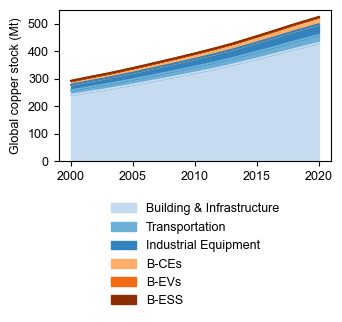

In [27]:
def plot_area(df, name):
    
    df = df / 1e3 # from kt to Mt
    year_min=2000
    year_max=2020
    df = df.loc[year_min:year_max,]
    
    fig, ax = plt.subplots(1,1, figsize=(3.5, 2))
    
    df_s = df.T.groupby(['Sector']).sum().T
    df_s.plot.area(ax=ax, y=Agg_Sectors, color=Agg_Sector_Colors, legend=False)

    ax.set_ylabel('Global copper '+ name +' (Mt)')
    #ax.set_xlim(year_min,year_max)
    #ax.set_ylim(0,500)
    ax.set_xlabel('')
    #ax.set_xticks(np.arange(year_min,year_max+1,5))
        
    plt.tight_layout()
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), frameon=False)
    
    #plt.savefig(file_path + r'Sector_Cu_Ni_Co\His_Copper.png', bbox_inches='tight', pad_inches=.1, dpi=300)
    plt.show()

plot_area(df_sectors_stock_2, 'stock')

In [28]:
def agg_world_results(df_inflow, df_stock, df_outflow, df_dissipation, df_para, df_scrap_r, df_stat):
    
    df_apc = pd.DataFrame(index=df_inflow.index, columns=df_inflow.columns)
    df_dissip = df_apc.copy()
    for sector in df_apc.columns:
        df_apc[sector] = df_inflow[sector] / (1-df_dissipation.at[sector, 'Dissipation rate'])
        df_dissip[sector] = df_apc[sector] * df_dissipation.at[sector, 'Dissipation rate']
    
    ################# 起算点
    df_world = pd.DataFrame(index=df_apc.index)
    df_world['Inflow'] = df_inflow.sum(axis=1)
    df_world['P4_P5'] = df_apc.sum(axis=1)
    df_world['P5_E0'] = df_dissip.sum(axis=1)
    
    ################# 往后算
    ## Outflow
    df_world['Stock'] = df_stock.sum(axis=1)
    df_world['Outflow'] = df_outflow.sum(axis=1)
    df_world['P5_P6'] = df_outflow.sum(axis=1)
    
    ## Secondary supply
    df_old_sec = pd.DataFrame(index=df_outflow.index, columns=df_outflow.columns)
    for sector in New_Sectors:
        df_old_sec[sector] = df_outflow[sector] *  df_para['Constant','old scrap collection rate']
    df_world['P6_P3'] = df_old_sec.sum(axis=1)
    df_world['P6_E0'] = df_world['P5_P6'] - df_world['P6_P3']
    
    ################ 往前算
    df_world['Total_manufacturing_input'] = df_world['P4_P5'] / (1-df_para['Constant','manufacturing loss rate'])
    df_world['P4_P3'] = df_world['Total_manufacturing_input'] * df_para['Constant','manufacturing loss rate'] * df_para['Constant','new scrap collection rate']
    df_world['P4_E0'] = df_world['Total_manufacturing_input'] - df_world['P4_P5'] - df_world['P4_P3'] 

    df_world['P3_P4'] = df_world['P4_P3']*df_scrap_r.at['Clean scrap ratio of new scrap','Value'] + df_world['P6_P3']*df_scrap_r.at['Clean scrap ratio of old scrap','Value']
    df_world['P2_P4'] = df_world['Total_manufacturing_input'] - df_world['P3_P4']
    
    df_world['P3_P2'] = (df_world['P4_P3'] * (1-df_scrap_r.at['Clean scrap ratio of new scrap','Value']) + df_world['P6_P3'] * (1-df_scrap_r.at['Clean scrap ratio of old scrap','Value'])) * (df_para['Constant','recycling efficiency'])
    df_world['P3_E0'] = (df_world['P4_P3'] * (1-df_scrap_r.at['Clean scrap ratio of new scrap','Value']) + df_world['P6_P3'] * (1-df_scrap_r.at['Clean scrap ratio of old scrap','Value'])) * (1-df_para['Constant','recycling efficiency'])
    
    df_world['P1_P2'] = (df_world['P2_P4']-df_world['P3_P2']) / (1-df_para['Constant','refining loss rate']) / (1-df_para['Constant','smelting loss rate'])
    df_world['P2_E0'] = df_world['P1_P2'] + df_world['P3_P2'] - df_world['P2_P4']
    
    df_world['L0_P1'] = df_world['P1_P2'] / (1-df_para['Constant','benefication loss rate']) / (1-df_para['Constant','mining loss rate'])
    df_world['P1_E0'] = df_world['L0_P1'] - df_world['P1_P2']

    ################ 与统计数据进行比较
    df_world['Mining'] = df_stat['mine_production']
    df_world['Refining'] = df_stat['refining_total']
    df_world['smelter_secondary'] = df_stat['smelter_secondary']
    df_world['refining_secondary'] = df_stat['refining_secondary']
    df_world['smelter_primary'] = df_stat['smelter_primary']
    df_world['refining_primary'] = df_stat['refining_primary']
    df_world = df_world[['L0_P1','P1_P2','Mining','P2_P4','Total_manufacturing_input','Refining','P4_P5','Inflow','Stock','Outflow','P5_P6',
                         'P6_P3','P4_P3','P3_P4','P3_P2','smelter_secondary','refining_secondary','smelter_primary','refining_primary',
                         'P1_E0','P2_E0','P3_E0','P4_E0','P5_E0','P6_E0']]
    return df_world


df_world_flow = agg_world_results(df_sectors_inflow, df_sectors_stock, df_sectors_outflow, df_dissipation_rate, df_parameters, df_scrap_ratio, df_world_statistics)

df_world_flow['EoL-RR'] = df_world_flow['P6_P3'] / df_world_flow['Outflow'] 
df_world_flow['EoL-RIR'] = df_world_flow['P6_P3'] / df_world_flow['Inflow']
df_world_flow['Mining_Variance'] = (df_world_flow['P1_P2'] - df_world_flow['Mining']) / df_world_flow['Mining'] *100
df_world_flow['Refining_Variance'] = (df_world_flow['P2_P4'] - df_world_flow['Refining']) / df_world_flow['Refining'] *100
#df_world_flow.to_excel('test_Copper.xlsx')

In [29]:
pd.set_option('display.max_columns', None)
df_world_flow.loc[2020:2030,:]

,L0_P1,P1_P2,Mining,P2_P4,Total_manufacturing_input,Refining,P4_P5,Inflow,Stock,Outflow,P5_P6,P6_P3,P4_P3,P3_P4,P3_P2,smelter_secondary,refining_secondary,smelter_primary,refining_primary,P1_E0,P2_E0,P3_E0,P4_E0,P5_E0,P6_E0,EoL-RR,EoL-RIR,Mining_Variance,Refining_Variance
Region,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2020,25818.910912,20791.916545,20656.609,23877.711340,29678.266711,24970.0,24632.961370,24527.497215,524635.564846,10929.579452,10929.579452,4918.310753,4641.680914,5800.555371,3458.681392,3340.0,3970.0,17500.0,21000.0,5026.994367,372.886598,300.754904,403.624427,105.464155,6011.268699,0.45,0.200522,0.655033,-4.374404
2021,27051.052190,21784.157415,21200.000,24958.596117,30990.773156,25350.0,25722.341720,25612.213466,539002.554003,11245.224309,11245.224309,5060.350939,4846.956922,6032.177039,3565.120356,3450.0,4250.0,17800.0,21100.0,5266.894775,390.681654,310.010466,421.474515,110.128254,6184.873370,0.45,0.197576,2.755460,-1.544000
2022,27592.732772,22220.371688,21900.000,25487.632485,31663.156795,25900.0,26280.420140,26167.902515,553597.268911,11573.187607,11573.187607,5207.934423,4952.117723,6175.524310,3665.765609,NaN,4403.0,NaN,21497.0,5372.361084,398.504812,318.762227,430.618932,112.517625,6365.253184,0.45,0.199020,1.462884,-1.592153
2023,28845.157386,23228.946687,22600.000,26592.326708,33007.924072,27000.0,27396.576980,27279.280614,568961.384732,11915.164794,11915.164794,5361.824157,5162.439325,6415.597364,3779.972828,NaN,4590.0,NaN,22410.0,5616.210699,416.592808,328.693289,448.907767,117.296365,6553.340636,0.45,0.196553,2.782950,-1.509901
2024,30103.983623,24242.676900,23000.000,27706.456177,34366.274857,27600.0,28524.008131,28401.884755,585091.068607,12272.200879,12272.200879,5522.490396,5374.885388,6659.818679,3898.552536,NaN,4692.0,NaN,22908.0,5861.306722,434.773258,339.004568,467.381338,122.123376,6749.710484,0.45,0.194441,5.402943,0.385711
2025,20499.331372,16508.069940,NaN,20086.381681,25561.753657,NaN,21216.255535,21110.904699,593560.225622,12641.747684,12641.747684,5688.786458,3997.858272,5475.371976,3874.370934,NaN,NaN,NaN,NaN,3991.261432,296.059193,336.901820,347.639850,105.350836,6952.961226,0.45,0.269471,NaN,NaN
2026,20621.182669,16606.196542,NaN,20295.053935,25871.804920,NaN,21473.598084,21365.846552,601895.528578,13030.543596,13030.543596,5863.744618,4046.350289,5576.750985,3986.676409,NaN,NaN,NaN,NaN,4014.986127,297.819016,346.667514,351.856547,107.751531,7166.798978,0.45,0.274445,NaN,NaN
2027,21391.581281,17226.596981,NaN,21030.600422,26798.219087,NaN,22242.521842,22130.561696,610588.370774,13437.719500,13437.719500,6046.973775,4191.241465,5767.618664,4112.948850,NaN,NaN,NaN,NaN,4164.984300,308.945408,357.647726,364.455780,111.960146,7390.745725,0.45,0.273241,NaN,NaN
2028,22205.038213,17881.672196,NaN,21806.401063,27774.895009,NaN,23053.162858,22936.849966,619660.576130,13864.644609,13864.644609,6239.090074,4343.993579,5968.493946,4245.422531,NaN,NaN,NaN,NaN,4323.366016,320.693664,369.167177,377.738572,116.312892,7625.554535,0.45,0.272012,NaN,NaN


In [30]:
df_world_flow.loc[2000:2024,:]

,L0_P1,P1_P2,Mining,P2_P4,Total_manufacturing_input,Refining,P4_P5,Inflow,Stock,Outflow,P5_P6,P6_P3,P4_P3,P3_P4,P3_P2,smelter_secondary,refining_secondary,smelter_primary,refining_primary,P1_E0,P2_E0,P3_E0,P4_E0,P5_E0,P6_E0,EoL-RR,EoL-RIR,Mining_Variance,Refining_Variance
Region,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2000,16447.223302,13192.963528,13209.463000,14902.401959,18391.340249,14733.4320,15264.812407,15200.551708,291984.194063,6061.772633,6061.772633,2727.797685,2876.405615,3488.938289,1946.043809,1049.082,2016.560,9060.875,12788.4740,3254.259773,236.605378,169.221201,250.122227,64.260699,3333.974948,0.45,0.179454,-0.124906,1.146847
2001,16839.097626,13446.825205,13689.841000,15207.787085,18778.224246,15412.5720,15585.926125,15520.261919,301260.588530,6243.867452,6243.867452,2809.740354,2936.914272,3570.437162,2002.120067,1067.106,1755.212,10450.988,13705.7250,3392.272421,241.158187,174.097397,255.383850,65.664205,3434.127099,0.45,0.181037,-1.775154,-1.328687
2002,16271.903771,13196.670331,13647.317000,15011.872678,18582.966143,15540.8710,15423.861899,15358.825168,310186.045680,6433.368018,6433.368018,2895.015608,2906.375905,3571.093465,2051.874204,1370.662,1706.976,10437.386,13871.7920,3075.233440,236.671857,178.423844,252.728340,65.036731,3538.352410,0.45,0.188492,-3.302090,-3.403917
2003,16102.089096,13125.139051,13802.118000,14996.496672,18599.115822,15263.0390,15437.266132,15372.117500,318927.808924,6630.354255,6630.354255,2983.659415,2908.901715,3602.619150,2106.746621,1421.813,1653.471,10448.393,13616.5680,2976.950046,235.389000,183.195358,252.947975,65.148632,3646.694840,0.45,0.194096,-4.904892,-1.746325
2004,17599.786050,14324.618985,14696.883000,16252.801171,20096.610711,15927.0510,16680.186890,16609.732998,328702.453598,6835.088324,6835.088324,3075.789746,3143.109915,3843.809540,2185.082912,1529.389,1985.711,10499.625,13969.3400,3275.167066,256.900725,190.007210,273.313906,70.453892,3759.298578,0.45,0.185180,-2.532945,2.045264
2005,17764.312090,14645.312973,15040.683000,16633.344764,20576.070195,16491.5120,17078.138262,17005.942184,338661.676658,7046.719124,7046.719124,3171.023606,3218.097378,3942.725430,2250.683909,1665.016,2039.101,11047.315,14489.7110,3118.999117,262.652118,195.711644,279.834555,72.196077,3875.695518,0.45,0.186466,-2.628671,0.860035
2006,18199.675512,14990.061727,15065.738006,17039.891704,21086.993686,17305.2010,17502.204760,17428.153122,348824.531790,7265.297990,7265.297990,3269.384096,3298.005813,4047.101983,2318.664891,2065.061,2597.220,11345.018,14707.9810,3209.613785,268.834915,201.623034,286.783114,74.051638,3995.913895,0.45,0.187592,-0.502307,-1.533119
2007,19135.370315,15655.587149,15503.562329,17768.780387,21974.250369,17909.1930,18238.627806,18161.394836,359495.189255,7490.737371,7490.737371,3370.831817,3436.772758,4205.469981,2393.963826,2153.023,2791.397,11494.180,15117.7960,3479.783165,280.770588,208.170767,298.849805,77.232970,4119.905554,0.45,0.185604,0.980580,-0.784025
2008,19434.640423,15632.175869,15583.038484,17811.342253,22063.825902,18287.1380,18312.975498,18235.361869,370008.130146,7722.420978,7722.420978,3475.089440,3450.782371,4252.483649,2459.517109,2234.337,2809.294,11775.565,15477.8440,3802.464554,280.350725,213.871053,300.068032,77.613629,4247.331538,0.45,0.190569,0.315326,-2.601805


In [31]:
df_world_flow.loc[2000:2024,:].sum() / 1000

L0_P1                          557.813253
P1_P2                          449.080054
Mining                         441.936468
P2_P4                          511.565977
Total_manufacturing_input      633.640809
Refining                       518.170908
P4_P5                          525.921871
Inflow                         523.683710
Stock                        10612.753959
Outflow                        221.438056
P5_P6                          221.438056
P6_P3                           99.647125
P4_P3                           99.101422
P3_P4                          122.074832
P3_P2                           70.539819
smelter_secondary               53.795717
refining_secondary              82.825269
smelter_primary                289.005291
refining_primary               435.162907
P1_E0                          108.733199
P2_E0                            8.053896
P3_E0                            6.133897
P4_E0                            8.617515
P5_E0                            2

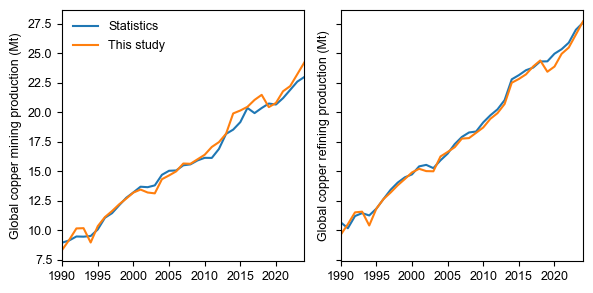

In [32]:
def plot_variance(df):
    
    year_min=1990
    year_max=2024
    df = df.loc[year_min:year_max,]
    df = df/1000  ## from kt to Mt
    
    fig, axes = plt.subplots(1,2, figsize=(6, 3), sharex=True, sharey=True)
    
    axes[0].plot(df.index, df.Mining, label='Statistics')
    axes[0].plot(df.index, df.P1_P2, label='This study')
    
    axes[1].plot(df.index, df.Refining, label='Statistics')
    axes[1].plot(df.index, df.P2_P4, label='This study')

    axes[0].set_ylabel('Global copper mining production (Mt)')
    axes[1].set_ylabel('Global copper refining production (Mt)')
    
    axes[0].legend(frameon=False, loc=2)
    
    for ax in axes:
        ax.set_xlim(year_min,year_max)
        ax.set_xlabel('')
        ax.set_xticks(np.arange(year_min,year_max+1,5))
        
    plt.tight_layout()
    
    plt.savefig(file_path + 'Sector_Cu_Ni_Co/His_Copper_Variance.png', bbox_inches='tight', pad_inches=.1, dpi=300)
    plt.show()

    
plot_variance(df_world_flow)

In [33]:
end_time = time.time()
execution_time = end_time - start_time
hours = execution_time // 3600 
minutes = (execution_time % 3600) // 60 
seconds = execution_time % 60 

print(f"代码运行时间: {int(hours)}小时 {int(minutes)}分钟 {int(seconds)}秒")

代码运行时间: 0小时 0分钟 39秒
